# Assignment 3: Customer Churn Prediction

Name: Iqra Mushtaq

This notebook loads the telco churn data, cleans it, builds a neural network, improves it, and checks how good it is.

## Upload the file in Colab

Click the upload icon in the Files panel on the left and choose the CSV file. After that this code will work.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Load and clean the data

In [25]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [27]:
# TotalCharges should be a number but it is text, and some values are blank spaces.
# Change it to a number. Blank values become NaN, then we fill them with 0.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Missing values now:", df.isnull().sum().sum())

Missing values now: 0


In [28]:
# customerID is just an ID, it does not help prediction, so drop it
df = df.drop(columns=['customerID'])

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


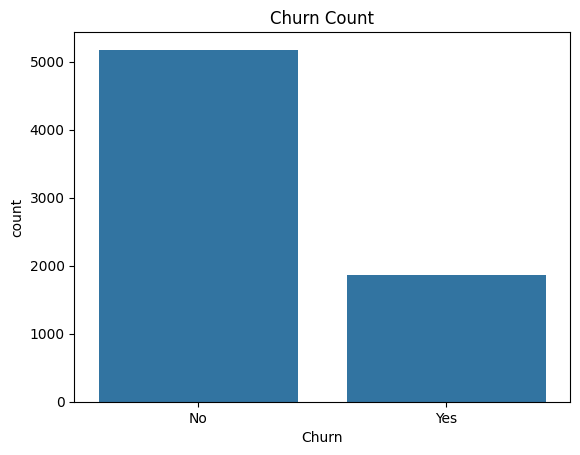

In [29]:
# Check if churn is balanced or not
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

sns.countplot(x='Churn', data=df)
plt.title('Churn Count')
plt.show()

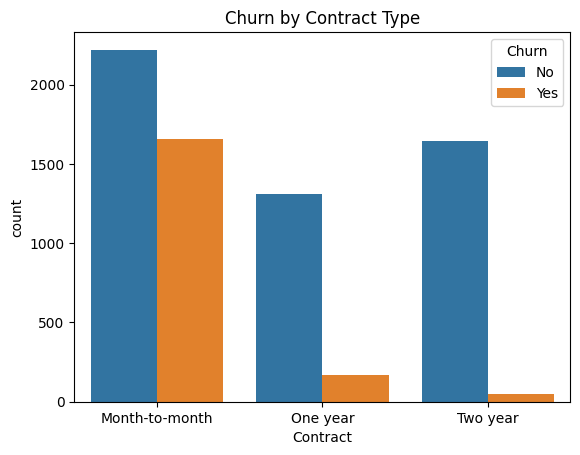

In [30]:
# Churn vs Contract type
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

Churn is not balanced. About 73 percent customers did not churn and 27 percent churned. People with month to month contract churn much more than people with one year or two year contract.

## Task 2: Prepare data for the neural network

In [31]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [32]:
# Columns with only 2 options (like Yes/No) get label encoding (0 or 1)
# Columns with more than 2 options (like Contract) get one hot encoding
# We use one hot encoding for multi option columns so the model does not think one option is bigger than another

binary_cols = [c for c in categorical_cols if df[c].nunique() == 2]
multi_cols = [c for c in categorical_cols if df[c].nunique() > 2]

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
print(df.shape)

(7043, 31)


In [33]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(5634, 30) (1409, 30)


## Task 3: Build and train the first model

In [34]:
input_size = X_train_scaled.shape[1]

model1 = keras.Sequential([
    layers.Input(shape=(input_size,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history1 = model1.fit(X_train_scaled, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=0)

loss1, acc1 = model1.evaluate(X_test_scaled, y_test, verbose=0)
print("Test accuracy:", acc1)
print("Test loss:", loss1)

Test accuracy: 0.7665010690689087
Test loss: 0.4748751223087311


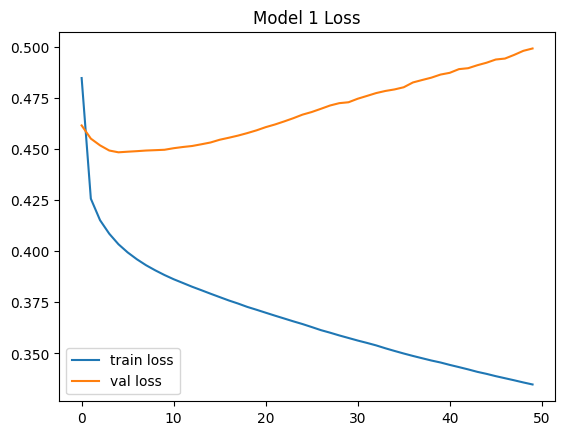

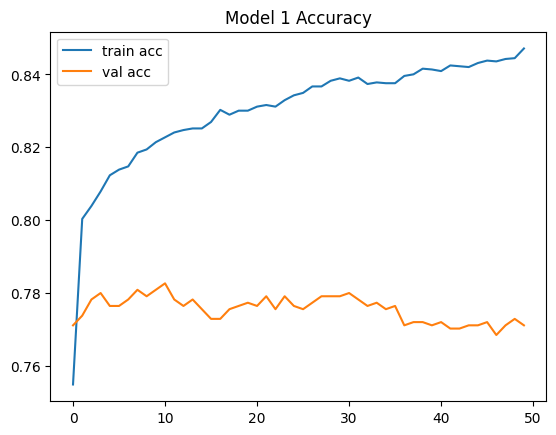

In [15]:
plt.plot(history1.history['loss'], label='train loss')
plt.plot(history1.history['val_loss'], label='val loss')
plt.legend()
plt.title('Model 1 Loss')
plt.show()

plt.plot(history1.history['accuracy'], label='train acc')
plt.plot(history1.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Model 1 Accuracy')
plt.show()

## Task 4: Make the model better

We add Dropout, Batch Normalization, and Early Stopping to reduce overfitting.

In [16]:
model2 = keras.Sequential([
    layers.Input(shape=(input_size,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 192 (768.00 B)

In [17]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history2 = model2.fit(X_train_scaled, y_train, validation_split=0.2, epochs=100,
                       batch_size=32, callbacks=[early_stop], verbose=0)

loss2, acc2 = model2.evaluate(X_test_scaled, y_test, verbose=0)
print("Test accuracy:", acc2)
print("Test loss:", loss2)

Test accuracy: 0.7892122268676758
Test loss: 0.43020498752593994


In [18]:
print("Before tuning (Model 1) accuracy:", acc1)
print("After tuning (Model 2) accuracy:", acc2)

Before tuning (Model 1) accuracy: 0.7665010690689087
After tuning (Model 2) accuracy: 0.7892122268676758


## Task 5: Check the model properly

In [19]:
best_model = model2 if acc2 >= acc1 else model1

y_pred_prob = best_model.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7892122072391767
Precision: 0.6142433234421365
Recall: 0.553475935828877
F1 score: 0.5822784810126582
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1035
           1       0.61      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



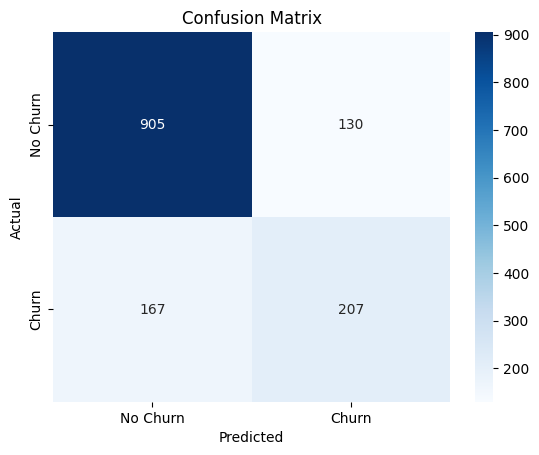

In [20]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Accuracy alone can be misleading here. Since about 73 percent of customers did not churn, a model could just guess "No" every time and still get 73 percent accuracy without finding any real churners. Precision, recall and F1 score show us better how well the model finds the customers who actually churn.

## Task 6: Save the model and predict on a new customer

In [21]:
best_model.save("best_churn_model.keras")
print("Model saved")

Model saved


In [22]:
raw_binary_values = {col: pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")[col] for col in binary_cols}

def predict_new_customer(customer_dict, model_path="best_churn_model.keras"):
    loaded_model = keras.models.load_model(model_path)
    new_df = pd.DataFrame([customer_dict])

    for col in binary_cols:
        new_df[col] = LabelEncoder().fit(raw_binary_values[col]).transform(new_df[col])

    new_df = pd.get_dummies(new_df, columns=[c for c in multi_cols if c in new_df.columns])
    new_df = new_df.reindex(columns=X.columns, fill_value=0)

    new_scaled = scaler.transform(new_df)
    prob = loaded_model.predict(new_scaled, verbose=0)[0][0]
    result = "Yes" if prob > 0.5 else "No"
    print("Churn probability:", prob)
    print("Will churn:", result)

In [23]:
new_customer = {
    'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No',
    'tenure': 5, 'PhoneService': 'Yes', 'MultipleLines': 'No',
    'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'No', 'StreamingMovies': 'No',
    'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.0, 'TotalCharges': 425.0
}

predict_new_customer(new_customer)

Churn probability: 0.69031537
Will churn: Yes


## Task 7: CNN vs RNN

We use a CNN when the data is like an image, where nearby pixels matter and we look for patterns like edges and shapes. Example: checking an X-ray to see if a patient has pneumonia.

We use an RNN when the data is a sequence and order matters, because the model remembers what came before. Example: predicting the next word while typing, or predicting tomorrow's stock price from past prices.